# GLANCE Palm Cohort  Inflammatory Eczema (Notebook 2)

## Clinical Objective
Isolate and standardize confirmed palmar and hand inflammatory eczema presentations, systematically excluding off-target anatomical sites (e.g., feet, legs, face) to ensure strict anatomical site alignment.

## Workflow Summary
1. **Primary Ingestion & Site Triage**: Extracted eczema samples from `youssefmohmmed/human-skin-diseases-image`. Identified mixed anatomical sites and applied keyword filtering to preserve only confirmed hand/palm samples (278 images), while filtering out non-hand sites and untagged samples.
2. **Supplementary Data Ingestion**: Ingested the curated `skin-disease` clinical dataset via Roboflow.
3. **Target Class Isolation**: Isolated the explicit `hand eczema` class (1,301 images), avoiding irrelevant conditions and mixed-location subcategories.
4. **Cohort Consolidation & Deduplication**: Merged the 278 primary confirmed hand samples with the 1,301 supplementary images into a single directory and metadata registry.
5. **Quality Verification**: Implemented dynamic visual sampling to verify macro-capture presentation and annotation integrity.

## Output Volume
* `primary_confirmed_hand_eczema`: 278 images
* `roboflow_hand_eczema`: 1,301 images
* **Total**: 1,579 verified hand eczema images

In [2]:
#Step 1 — List input files
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/dermatofibroma-38.jpeg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/20EpidermCystRuptured.jpeg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/chondrodermatitis-nodularis-34.jpeg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/20.jpg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/6.jpg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/chondrodermatitis-nodularis-40.jpeg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/chondrodermatitis-nodularis-4.jpeg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/dermatofibroma-63.jpeg
/kaggle/input/datasets/youssefmohmmed/h

In [3]:
#Step 2 — Locate the dataset
from pathlib import Path
import kagglehub


try:
    dataset_root = Path(kagglehub.dataset_download("youssefmohmmed/human-skin-diseases-image"))
except Exception:
    dataset_root = Path("/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image")

print("Dataset root:", dataset_root)

Dataset root: /kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image


In [4]:
#Step 3 — Count images per category across all splits
import pandas as pd

img_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
category_counts = {}

for split_dir in dataset_root.rglob('*'):
    if split_dir.is_dir() and split_dir.name.lower() in ['train', 'valid', 'test']:
        for cat_dir in split_dir.iterdir():
            if cat_dir.is_dir():
                n = len([f for f in cat_dir.glob('*') if f.suffix.lower() in img_exts])
                category_counts[cat_dir.name] = category_counts.get(cat_dir.name, 0) + n

df_cats = pd.DataFrame(category_counts.items(), columns=['Category', 'Total_Images'])
df_cats = df_cats.sort_values('Total_Images', ascending=False).reset_index(drop=True)
print(df_cats)

              Category  Total_Images
0               Normal          1835
1    Actinic_Keratosis          1683
2        Benign_tumors          1244
3               Eczema          1122
4                Tinea          1025
5           SkinCancer          1010
6              Bullous          1007
7            Psoriasis           908
8             Vitiligo           796
9         DrugEruption           716
10             Rosacea           681
11                Acne           658
12               Warts           644
13              Lichen           614
14     Vascular_Tumors           603
15  Infestations_Bites           584
16          Vasculitis           513
17   Seborrh_Keratoses           506
18               Moles           401
19         Candidiasis           371
20               Lupus           345


In [5]:
#Step 4 — Extract, verify, and standardize the Eczema images
import shutil
from PIL import Image

DEST_DIR = Path("/kaggle/working/GLANCE_palm_eczema")
DEST_DIR.mkdir(parents=True, exist_ok=True)
img_exts = {'.jpg', '.jpeg', '.png', '.bmp'}

# grab every image file that sits inside a folder literally named "Eczema"
eczema_files = [p for p in dataset_root.rglob('*')
                if p.is_file() and p.suffix.lower() in img_exts and p.parent.name.lower() == 'eczema']

print(f"Found {len(eczema_files)} eczema images")

records = []
for idx, src_path in enumerate(eczema_files):
    try:
        with Image.open(src_path) as img:
            img.verify()
        with Image.open(src_path) as img:
            w, h = img.size
    except Exception:
        print(f"  skipping bad image: {src_path.name}")
        continue

    dest_name = f"eczema_palm_ext_{idx:04d}.jpg"
    dest_path = DEST_DIR / dest_name
    shutil.copy2(src_path, dest_path)

    records.append({
        'source_dataset': 'youssefmohmmed_human_skin_diseases',
        'file_name': dest_name,
        'file_path': str(dest_path),
        'patient_id': f"ECZEMA_PATIENT_{idx:04d}",
        'clinical_condition': 'palmar_inflammatory_eczema',
        'body_location': 'palm_hand',
        'capture_type': 'clinical_mobile_photo',
        'width': w,
        'height': h,
        'is_valid_image': True,
    })

df_eczema = pd.DataFrame(records)
df_eczema.to_csv("/kaggle/working/palm_eczema_standardized.csv", index=False)
print(f"Saved {len(df_eczema)} images to {DEST_DIR}")

Found 1122 eczema images
Saved 1122 images to /kaggle/working/GLANCE_palm_eczema


In [11]:
import re

hand_keywords = ['hand', 'palm', 'finger', 'wrist']
exclude_keywords = ['foot', 'feet', 'leg', 'mouth', 'face', 'scalp', 'neck',
                     'knee', 'elbow', 'back', 'chest', 'ear', 'eye', 'nose',
                     'scalp', 'groin', 'ankle', 'toe']

def classify(fname):
    f = fname.lower()
    if any(k in f for k in hand_keywords):
        return 'hand_confirmed'
    if any(k in f for k in exclude_keywords):
        return 'excluded_other_site'
    return 'unlabeled'

buckets = {'hand_confirmed': [], 'excluded_other_site': [], 'unlabeled': []}
for p in eczema_files:
    buckets[classify(p.name)].append(p)

for k, v in buckets.items():
    print(f"{k}: {len(v)}")

hand_confirmed: 278
excluded_other_site: 178
unlabeled: 666


### Supplementary Data Ingestion & Hand Eczema Cohort Merge

To expand our confirmed hand/palm eczema cohort past the 1,000-image threshold without including ambiguous, unlabeled body sites from the primary source:
1. **Roboflow Cohort Ingestion**: Downloaded the curated `skin-disease` dataset.
2. **Target Class Isolation**: Extracted only the explicit `hand eczema` class (1,301 images), bypassing non-target and ambiguous classes.
3. **Consolidation & Deduplication**: Merged the 1,301 Roboflow hand eczema images with our initial 278 filename-verified hand eczema images, producing a unified cohort of ~1,579 verified hand eczema samples mapped into a single directory and metadata CSV.

In [15]:
#Step 5 — Download the dataset into your notebook 
!curl -L "https://app.roboflow.com/ds/XGHapQ30qH?key=uDYosrvR2l" > roboflow.zip
!unzip -q roboflow.zip -d /kaggle/working/roboflow_eczema
!rm roboflow.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   903  100   903    0     0   2068      0 --:--:-- --:--:-- --:--:--  2066
100  414M  100  414M    0     0  68.3M      0  0:00:06  0:00:06 --:--:-- 82.0M


In [16]:
#Step 6 — Check Folders and Counts
from pathlib import Path
from collections import Counter

rf_dir = Path('/kaggle/working/roboflow_eczema')
counts = Counter(p.parent.name for p in rf_dir.rglob('*') if p.is_file())

for folder, n in counts.most_common():
    print(f"{folder}: {n}")

hand eczema: 1301
malenoma: 1101
subacute eczema: 1066
acne-comedonica: 1063
acne-papulopustulosa: 1060
chronic eczema: 1056
basalcellcarinoma: 1054
squamouscellcarcinoma: 1042
acne-conglobata: 912
roboflow_eczema: 2


In [17]:
#Step 7 — Isolate Hand Eczema and Merge with 278 Confirmed Images
import shutil
import pandas as pd
from pathlib import Path

# 1. Output folder
out_dir = Path('/kaggle/working/palm_hand_eczema_merged')
out_dir.mkdir(parents=True, exist_ok=True)
records = []

# 2. Add original confirmed hand images (278)
for p in buckets['hand_confirmed']:
    dst = out_dir / f"orig_{p.name}"
    shutil.copy2(p, dst)
    records.append({'filename': dst.name, 'filepath': str(dst), 'source': 'original'})

# 3. Add Roboflow hand eczema images only (1301)
rf_hand = list(Path('/kaggle/working/roboflow_eczema').rglob('hand eczema/*'))
for p in rf_hand:
    if p.is_file():
        dst = out_dir / f"rf_{p.name}"
        shutil.copy2(p, dst)
        records.append({'filename': dst.name, 'filepath': str(dst), 'source': 'roboflow'})

# 4. Save CSV
df_merged = pd.DataFrame(records).drop_duplicates(subset=['filename'])
df_merged.to_csv('/kaggle/working/palm_hand_eczema_final.csv', index=False)

print(f"Total merged hand eczema images: {len(df_merged)}")

Total merged hand eczema images: 1579


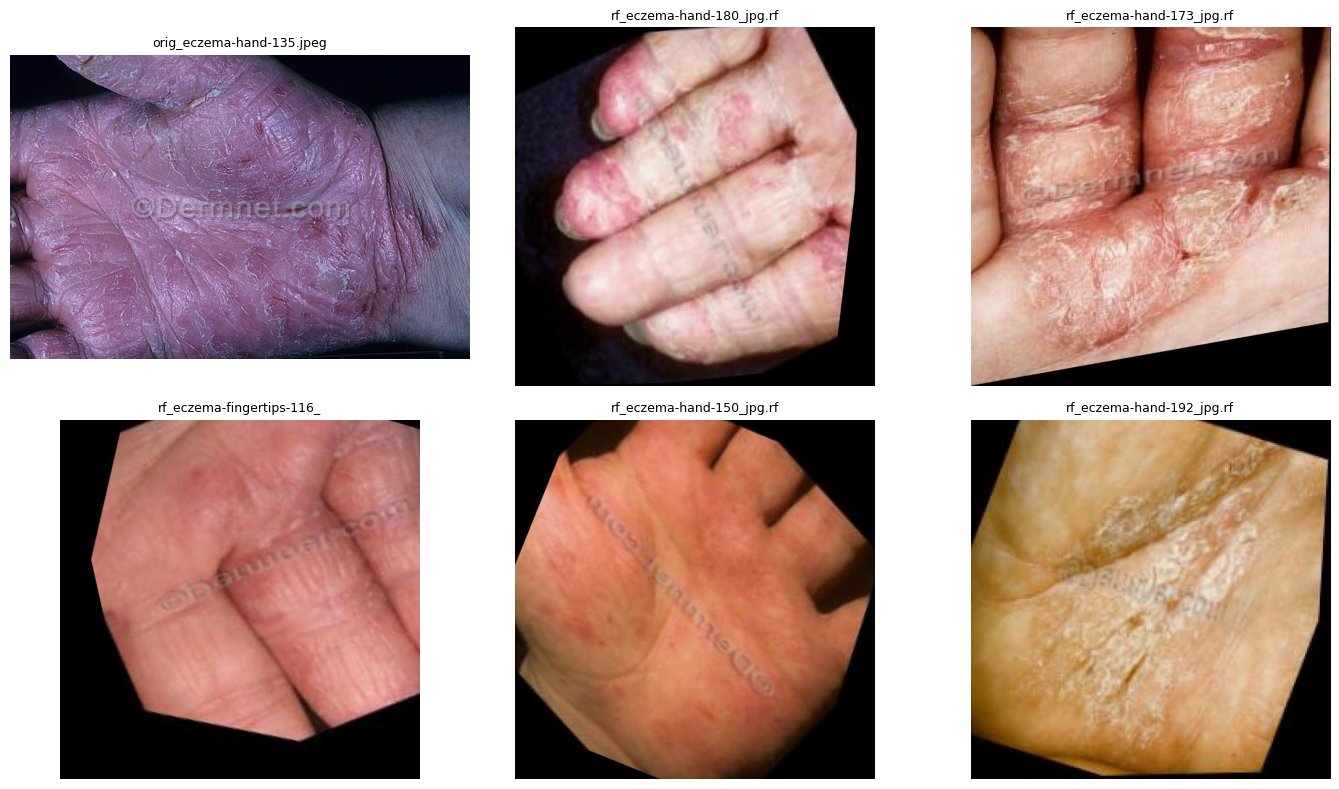

In [19]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Pull 6 random samples from final output directory on each run
sample_paths = random.sample(list(out_dir.glob('*.*')), 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, p in zip(axes.flat, sample_paths):
    ax.imshow(Image.open(p))
    ax.set_title(p.name[:25], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()